# imports

In [1]:
import pandas as pd
import numpy as np
import xgboost as xgb
from sklearn.metrics import (
    classification_report, accuracy_score, 
    precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay
)
import mlflow
import matplotlib.pyplot as plt
from sklearn.model_selection import GridSearchCV
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

c:\Users\Manindra\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# config

In [2]:
ASSET = "BTC"
INTERVAL = "4h"
VERSION = "v4_native"
HORIZON = "4h_native"

BASELINE_V2_ACCURACY = 0.5261   # v2: 1h target with OI+turnover
BASELINE_V3_ACCURACY = 0.5243   # v3: derived 4h target (1h candles × 4 shift)

# load data

In [3]:
train_df = pd.read_parquet('../../../data/processed/train_btc_4h_native.parquet')
test_df  = pd.read_parquet('../../../data/processed/test_btc_4h_native.parquet')

print(f"Train: {train_df.shape}")
print(f"Test:  {test_df.shape}")
print(f"Features ({len([c for c in train_df.columns if c not in ['target_4h', 'target_direction']])}):")
for i, c in enumerate([c for c in train_df.columns if c not in ['target_4h', 'target_direction']]):
    print(f"  {i+1:2d}. {c}")

Train: (10579, 35)
Test:  (2645, 35)
Features (33):
   1. rsi_14
   2. roc_10
   3. roc_20
   4. stoch_k
   5. stoch_d
   6. bb_percentage
   7. volume_ratio
   8. returns_1p
   9. returns_5p
  10. returns_10p
  11. returns_20p
  12. log_returns
  13. hl_ratio
  14. close_position
  15. turnover_ratio
  16. turnover_change_1p
  17. turnover_change_5p
  18. turnover_ratio_zscore_50
  19. sma_7_dist
  20. sma_30_dist
  21. sma_50_dist
  22. sma_100_dist
  23. sma_200_dist
  24. ema_12_dist
  25. ema_26_dist
  26. ema_50_dist
  27. ema_200_dist
  28. vwap_dist
  29. macd_pct
  30. macd_sig_pct
  31. macd_hist_pct
  32. atr_pct
  33. volatility_pct


# seaparate features and targets

In [4]:
y_train = train_df.pop('target_direction')
X_train = train_df.drop(columns=['target_4h'], errors='ignore')

y_test = test_df.pop('target_direction')
X_test = test_df.drop(columns=['target_4h'], errors='ignore')

print(f"X_train: {X_train.shape}  |  y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}   |  y_test:  {y_test.shape}")
print(f"Class balance (test): UP={(y_test==1).mean():.2%}  DOWN={(y_test==0).mean():.2%}")

X_train: (10579, 33)  |  y_train: (10579,)
X_test:  (2645, 33)   |  y_test:  (2645,)
Class balance (test): UP=50.06%  DOWN=49.94%


# mlflow

In [5]:
mlflow.set_tracking_uri("http://localhost:5000")
mlflow.set_experiment(f"{ASSET}_{HORIZON}_XGBoost")
mlflow.xgboost.autolog(disable=True)

2026/05/19 13:20:46 INFO mlflow.tracking.fluent: Experiment with name 'BTC_4h_native_XGBoost' does not exist. Creating a new experiment.


# baseline model without tuning

In [6]:
with mlflow.start_run(run_name=f"{ASSET}_{HORIZON}_XGBoost_Baseline"):
    mlflow.log_param("asset", ASSET)
    mlflow.log_param("interval", INTERVAL)
    mlflow.log_param("horizon", HORIZON)
    mlflow.log_param("n_features", X_train.shape[1])
    mlflow.log_param("train_rows", len(X_train))
    mlflow.log_param("test_rows", len(X_test))
    mlflow.log_param("run_type", "baseline")
    mlflow.log_param("note", "native 4h candles — true 4h data, not derived from 1h")
    
    baseline_model = xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=5,
        device='cuda',
        tree_method='hist',
        eval_metric='logloss',
        random_state=42
    )
    
    baseline_model.fit(X_train, y_train)
    y_pred_baseline = baseline_model.predict(X_test)
    
    baseline_acc  = accuracy_score(y_test, y_pred_baseline)
    baseline_prec = precision_score(y_test, y_pred_baseline)
    baseline_rec  = recall_score(y_test, y_pred_baseline)
    baseline_f1   = f1_score(y_test, y_pred_baseline)
    
    mlflow.log_params({
        "n_estimators": 100,
        "learning_rate": 0.1,
        "max_depth": 5
    })
    mlflow.log_metric("test_accuracy", baseline_acc)
    mlflow.log_metric("test_precision", baseline_prec)
    mlflow.log_metric("test_recall", baseline_rec)
    mlflow.log_metric("test_f1", baseline_f1)
    
    print(f"BASELINE (native 4h candles):")
    print(f"  Accuracy:  {baseline_acc:.4f}")
    print(f"  Precision: {baseline_prec:.4f}")
    print(f"  Recall:    {baseline_rec:.4f}")
    print(f"  F1:        {baseline_f1:.4f}")
    print(classification_report(y_test, y_pred_baseline, target_names=['DOWN', 'UP']))

BASELINE (native 4h candles):
  Accuracy:  0.5183
  Precision: 0.5163
  Recall:    0.5967
  F1:        0.5536
              precision    recall  f1-score   support

        DOWN       0.52      0.44      0.48      1321
          UP       0.52      0.60      0.55      1324

    accuracy                           0.52      2645
   macro avg       0.52      0.52      0.52      2645
weighted avg       0.52      0.52      0.52      2645

🏃 View run BTC_4h_native_XGBoost_Baseline at: http://localhost:5000/#/experiments/19/runs/fe26d676f7504d43882697646be40213
🧪 View experiment at: http://localhost:5000/#/experiments/19


# GridSearchCV (216 candidates)

In [7]:
with mlflow.start_run(run_name=f"{ASSET}_{HORIZON}_XGBoost_GridSearch"):
    mlflow.log_param("asset", ASSET)
    mlflow.log_param("interval", INTERVAL)
    mlflow.log_param("horizon", HORIZON)
    mlflow.log_param("n_features", X_train.shape[1])
    mlflow.log_param("train_rows", len(X_train))
    mlflow.log_param("test_rows", len(X_test))
    mlflow.log_param("baseline_v2_accuracy", BASELINE_V2_ACCURACY)
    mlflow.log_param("baseline_v3_accuracy", BASELINE_V3_ACCURACY)
    mlflow.log_param("run_type", "grid_search")
    mlflow.log_param("note", "native 4h candles — true 4h data")
    
    param_grid = {
        'max_depth':        [3, 5, 7],
        'learning_rate':    [0.01, 0.05, 0.1],
        'n_estimators':     [100, 200, 300],
        'subsample':        [0.8, 1.0],
        'colsample_bytree': [0.8, 1.0],
        'reg_alpha':        [0, 0.1],
    }
    
    total_combos = (
        len(param_grid['max_depth']) *
        len(param_grid['learning_rate']) *
        len(param_grid['n_estimators']) *
        len(param_grid['subsample']) *
        len(param_grid['colsample_bytree']) *
        len(param_grid['reg_alpha'])
    )
    print(f"Grid: {total_combos} candidates × 3 folds = {total_combos * 3} total fits")
    
    base_xgb = xgb.XGBClassifier(
        tree_method='hist',
        device='cuda',
        eval_metric='logloss',
        random_state=42
    )
    
    grid_search = GridSearchCV(
        estimator=base_xgb,
        param_grid=param_grid,
        scoring='accuracy',
        cv=3,
        verbose=1,
        n_jobs=1
    )
    
    grid_search.fit(X_train, y_train)
    
    best_model = grid_search.best_estimator_
    y_pred_tuned = best_model.predict(X_test)
    
    tuned_acc  = accuracy_score(y_test, y_pred_tuned)
    tuned_prec = precision_score(y_test, y_pred_tuned)
    tuned_rec  = recall_score(y_test, y_pred_tuned)
    tuned_f1   = f1_score(y_test, y_pred_tuned)
    
    delta_vs_baseline = tuned_acc - baseline_acc
    delta_vs_v2       = tuned_acc - BASELINE_V2_ACCURACY
    delta_vs_v3       = tuned_acc - BASELINE_V3_ACCURACY
    
    mlflow.log_params(grid_search.best_params_)
    mlflow.log_metric("test_accuracy",  tuned_acc)
    mlflow.log_metric("test_precision", tuned_prec)
    mlflow.log_metric("test_recall",    tuned_rec)
    mlflow.log_metric("test_f1",        tuned_f1)
    mlflow.log_metric("delta_vs_baseline_4h_native", delta_vs_baseline)
    mlflow.log_metric("delta_vs_v2_1h",              delta_vs_v2)
    mlflow.log_metric("delta_vs_v3_derived_4h",      delta_vs_v3)
    
    print(f"\nGRID SEARCH (native 4h candles):")
    print(f"  Best Params: {grid_search.best_params_}")
    print(f"  Best CV Score: {grid_search.best_score_:.4f}")
    print(f"  Test Accuracy:  {tuned_acc:.4f}")
    print(f"  Test Precision: {tuned_prec:.4f}")
    print(f"  Test Recall:    {tuned_rec:.4f}")
    print(f"  Test F1:        {tuned_f1:.4f}")
    print(classification_report(y_test, y_pred_tuned, target_names=['DOWN', 'UP']))

Grid: 216 candidates × 3 folds = 648 total fits
Fitting 3 folds for each of 216 candidates, totalling 648 fits

GRID SEARCH (native 4h candles):
  Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 0.1, 'subsample': 0.8}
  Best CV Score: 0.5486
  Test Accuracy:  0.5274
  Test Precision: 0.5245
  Test Recall:    0.5982
  Test F1:        0.5589
              precision    recall  f1-score   support

        DOWN       0.53      0.46      0.49      1321
          UP       0.52      0.60      0.56      1324

    accuracy                           0.53      2645
   macro avg       0.53      0.53      0.52      2645
weighted avg       0.53      0.53      0.53      2645

🏃 View run BTC_4h_native_XGBoost_GridSearch at: http://localhost:5000/#/experiments/19/runs/80666f82eed94cfc914051a8cb182fe1
🧪 View experiment at: http://localhost:5000/#/experiments/19


# featues importance

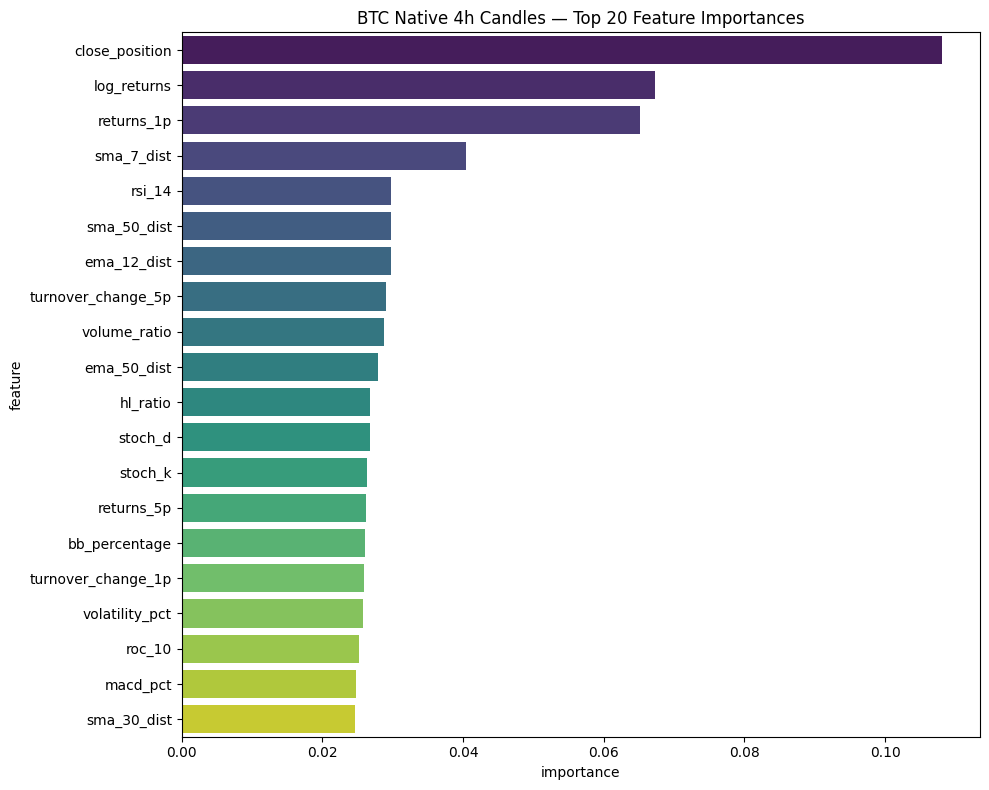

Top 10 features:
           feature  importance
    close_position    0.108080
       log_returns    0.067295
        returns_1p    0.065172
        sma_7_dist    0.040461
            rsi_14    0.029753
       sma_50_dist    0.029728
       ema_12_dist    0.029722
turnover_change_5p    0.029029
      volume_ratio    0.028759
       ema_50_dist    0.027965


In [8]:
importance_df = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(data=importance_df.head(20), y='feature', x='importance', palette='viridis')
plt.title(f'{ASSET} Native 4h Candles — Top 20 Feature Importances')
plt.tight_layout()
plt.show()

print("Top 10 features:")
print(importance_df.head(10).to_string(index=False))

# summary

In [11]:
print("=" * 60)
print(f"   RESULTS: {ASSET} Native 4h Candles  4h Target")
print("=" * 60)
print(f"  Data: true 4h candles (not derived from 1h)")
print(f"  Features: {X_train.shape[1]} (turnover, no OI — OI 100% NULL in 4h)")
print(f"  Train rows: {len(X_train):,}  |  Test rows: {len(X_test):,}")
print()
print(f"  v2 Baseline (1h target, OI+turnover):    {BASELINE_V2_ACCURACY:.4f}")
print(f"  v3 Derived 4h (1h candles × 4 shift):    {BASELINE_V3_ACCURACY:.4f}")
print(f"  v4 Baseline (native 4h, no tuning):      {baseline_acc:.4f}  {'↑' if baseline_acc > BASELINE_V2_ACCURACY else '↓'} {'IMPROVEMENT!' if baseline_acc > BASELINE_V2_ACCURACY else 'No improvement'}")
print(f"  v4 Tuned (native 4h, GridSearchCV):      {tuned_acc:.4f}  {'↑' if tuned_acc > BASELINE_V2_ACCURACY else '↓'} {'IMPROVEMENT!' if tuned_acc > BASELINE_V2_ACCURACY else 'No improvement'}")
print(f"  Best Params: {grid_search.best_params_}")
print(f"  GridSearch improvement over baseline: {delta_vs_baseline:+.4f}")
print(f"  Delta vs v2 (1h):      {delta_vs_v2:+.4f}")
print(f"  Delta vs v3 (derived): {delta_vs_v3:+.4f}")
print("=" * 60)
print(f"\nInterpretation:")
print(f"  - v2 ceiling (1h):           {BASELINE_V2_ACCURACY:.4f}")
print(f"  - v3 ceiling (derived 4h):   {BASELINE_V3_ACCURACY:.4f}")
print(f"  - If v4 native > v3 derived: true 4h candles capture signal better than derived")
print(f"  - If v4 native ≈ {BASELINE_V2_ACCURACY:.4f}: 52.6% ceiling holds regardless of data source")

   RESULTS: BTC Native 4h Candles  4h Target
  Data: true 4h candles (not derived from 1h)
  Features: 33 (turnover, no OI — OI 100% NULL in 4h)
  Train rows: 10,579  |  Test rows: 2,645

  v2 Baseline (1h target, OI+turnover):    0.5261
  v3 Derived 4h (1h candles × 4 shift):    0.5243
  v4 Baseline (native 4h, no tuning):      0.5183  ↓ No improvement
  v4 Tuned (native 4h, GridSearchCV):      0.5274  ↑ IMPROVEMENT!
  Best Params: {'colsample_bytree': 0.8, 'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 100, 'reg_alpha': 0.1, 'subsample': 0.8}
  GridSearch improvement over baseline: +0.0091
  Delta vs v2 (1h):      +0.0013
  Delta vs v3 (derived): +0.0031

Interpretation:
  - v2 ceiling (1h):           0.5261
  - v3 ceiling (derived 4h):   0.5243
  - If v4 native > v3 derived: true 4h candles capture signal better than derived
  - If v4 native ≈ 0.5261: 52.6% ceiling holds regardless of data source
